[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/skarma91/logicmojo-ai-july-2026/blob/main/modules/module-2-ml-dl-essentials/03-neural-networks/code/neural_network_basics.ipynb)

# Class 2.3: Neural networks

The slides build the intuition. Here you build a network by hand in NumPy: one neuron, activations, a layer, a forward pass, softmax, and cross-entropy. Every number ties back to a formula on the slides.

What we will cover:
- a neuron: weighted sum plus activation
- ReLU and sigmoid, plotted
- a layer of neurons, and why stacked linear layers collapse to one
- softmax and cross-entropy
- a full two-layer forward pass


## A neuron

Weigh the inputs, add a bias to get `z`, then pass `z` through an activation. This example uses three inputs, distinct from the two-input neuron on the slides.

In [1]:
import numpy as np

x = np.array([1.0, 2.0, 3.0])
w = np.array([0.2, -0.5, 0.4])
b = 0.5

z = np.dot(w, x) + b
print("z =", round(float(z), 3))
print("ReLU(z)    =", round(float(max(0.0, z)), 3))
print("sigmoid(z) =", round(float(1 / (1 + np.exp(-z))), 3))

z = 0.9
ReLU(z)    = 0.9
sigmoid(z) = 0.711


## Activation functions, plotted

ReLU keeps positives and zeroes negatives. Sigmoid squashes any number into 0 to 1. Tanh squashes any number between -1 to +1. Seeing the shapes makes the vanishing-gradient point concrete: sigmoid is flat at both ends.

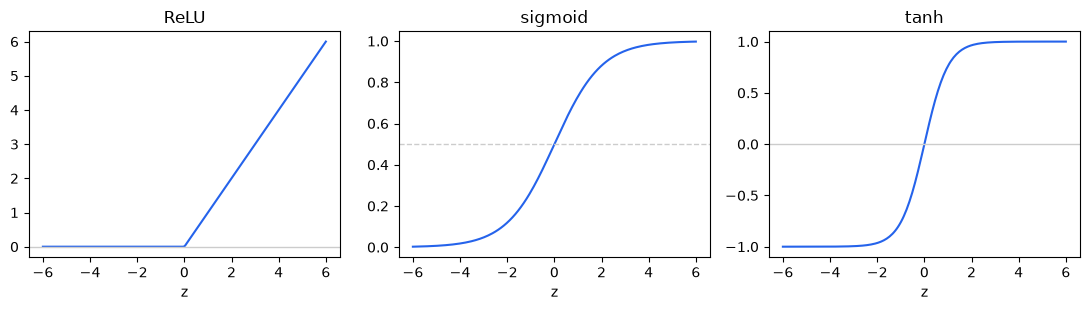

In [2]:
import matplotlib.pyplot as plt
%matplotlib inline

def relu(z):    return np.maximum(0, z)
def sigmoid(z): return 1 / (1 + np.exp(-z))
def tanh(z):    return np.tanh(z)

zs = np.linspace(-6, 6, 200)
fig, ax = plt.subplots(1, 3, figsize=(11, 3.2))
ax[0].plot(zs, relu(zs), color="#2563eb");    ax[0].set_title("ReLU");    ax[0].axhline(0, color="#cccccc", lw=1)
ax[1].plot(zs, sigmoid(zs), color="#2563eb"); ax[1].set_title("sigmoid"); ax[1].axhline(0.5, color="#cccccc", lw=1, ls="--")
ax[2].plot(zs, tanh(zs), color="#2563eb");    ax[2].set_title("tanh");    ax[2].axhline(0, color="#cccccc", lw=1)
for a in ax: a.set_xlabel("z")
plt.tight_layout(); plt.show()

## A layer: several neurons at once

A layer is a weight matrix: one row per neuron. One matrix-vector product computes every neuron's `z` in a single step.

In [3]:
W = np.array([[0.2, -0.5, 0.4],
              [0.1,  0.3, -0.2]])   # 2 neurons, 3 inputs each
b_layer = np.array([0.5, 0.0])

z_layer = W @ x + b_layer
a_layer = relu(z_layer)
print("z per neuron:", np.round(z_layer, 3))
print("a per neuron:", np.round(a_layer, 3))
print("parameters here:", W.size, "weights +", b_layer.size, "biases =", W.size + b_layer.size)

z per neuron: [0.9 0.1]
a per neuron: [0.9 0.1]
parameters here: 6 weights + 2 biases = 8


## Why activations matter: linear stacks collapse

Two linear layers with no activation are just one linear layer. Compute the output both ways and see them match, which is why a nonlinearity is required to gain any power from depth.

In [4]:
W1 = np.array([[0.5, -0.2, 0.1], [0.0, 0.4, -0.3]])   # layer 1: 3 -> 2
b1 = np.array([0.1, -0.2])
W2 = np.array([[1.0, -1.0]])                          # layer 2: 2 -> 1
b2 = np.array([0.5])

two_layers = W2 @ (W1 @ x + b1) + b2                  # no activation between them
W_combined = W2 @ W1
b_combined = W2 @ b1 + b2
one_layer = W_combined @ x + b_combined

print("through two layers:", np.round(two_layers, 6))
print("through one combined layer:", np.round(one_layer, 6))
print("identical:", np.allclose(two_layers, one_layer))

through two layers: [1.3]
through one combined layer: [1.3]
identical: True


## Softmax: scores into probabilities

In [5]:
def softmax(z):
    e = np.exp(z - np.max(z))   # subtract max for numerical stability
    return e / e.sum()

logits = np.array([2.0, 1.0, 0.1])
probs = softmax(logits)
print("logits:", logits)
print("probs :", np.round(probs, 3))
print("sum   :", round(float(probs.sum()), 3))

logits: [2.  1.  0.1]
probs : [0.659 0.242 0.099]
sum   : 1.0


## Cross-entropy: the classification loss

Cross-entropy compares the predicted probabilities to a one-hot target `y`: it is `-sum(y * log(p))`. Because `y` is 1 for the true class and 0 elsewhere, it collapses to `-log(p_true)`. A confident wrong answer costs the most.

In [6]:
true_class = 0
y = np.zeros_like(probs); y[true_class] = 1.0     # one-hot target

ce = -np.sum(y * np.log(probs))                   # -sum(y * log p)
print("one-hot target y:", y)
print("cross-entropy -sum(y*log p):", round(float(ce), 3))
print("same as -log(p_true)      :", round(float(-np.log(probs[true_class])), 3))

# a confident-wrong case, for contrast
wrong = softmax(np.array([0.1, 2.5, 0.1]))
print("if confidently wrong, loss =", round(float(-np.log(wrong[true_class])), 3))

one-hot target y: [1. 0. 0.]
cross-entropy -sum(y*log p): 0.417
same as -log(p_true)      : 0.417
if confidently wrong, loss = 2.567


## A full two-layer forward pass

Input, a hidden layer with ReLU, an output layer, then softmax. This is the whole forward pass, end to end.

In [7]:
Wh = np.array([[0.2, -0.5, 0.4],
               [0.1,  0.3, -0.2],
               [-0.3, 0.2, 0.5]])    # hidden: 3 -> 3
bh = np.array([0.1, 0.0, -0.1])
Wo = np.array([[0.6, -0.1, 0.2],
               [0.1,  0.4, -0.3]])   # output: 3 -> 2 classes
bo = np.array([0.0, 0.1])

hidden = relu(Wh @ x + bh)
logits_out = Wo @ hidden + bo
probs_out = softmax(logits_out)
print("hidden activations:", np.round(hidden, 3))
print("output logits     :", np.round(logits_out, 3))
print("class probabilities:", np.round(probs_out, 3), " sum", round(float(probs_out.sum()), 3))

hidden activations: [0.5 0.1 1.5]
output logits     : [ 0.59 -0.26]
class probabilities: [0.701 0.299]  sum 1.0


## Your turn

**Micro-assignment.** Six problems in NumPy; see `../micro-assignment/README.md`.

**Next, class 2.4 (PyTorch fundamentals):** tensors, automatic gradients, losses and optimizers, and the five-line training loop for real.